# Pointwise Error Heatmaps: SparseGT vs TAGConv (Philadelphia)

Compare spatial error distributions across all runs (SparseGT and TAGConv)
on Philadelphia terrain graphs at resolution 10 (`e27TR_philly_hybrid_sampling`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import wandb
import wandb_buddy as wb
from pathlib import Path

In [2]:
ENTITY = "alelab"
PROJECT = "manifold-transformers-dev"
TAG = "e27TR_philly_hybrid_sampling"
RESOLUTION = 10
EXCLUDE_WORST_RUN = True
SPARSE_GT_EPOCHS = 20

REPO_ROOT = Path("/home/teresa/shortest-paths-nn")
TEST_DATA_PATH = REPO_ROOT / "data" / "generated2" / "philly_test_res04.npz"

In [3]:
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG], state="all")
print(f"Total runs with tag '{TAG}': {len(df)}")

if "layer_type" not in df.columns:
    df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)
if "resolution" not in df.columns:
    df["resolution"] = (
        df["name"].str.extract(r"res(\d+)", expand=False).astype(float)
    )
df = df.dropna(subset=["layer_type", "resolution"])
df["resolution"] = df["resolution"].astype(int)

mae_candidates = [c for c in df.columns if "test_mae" in c.lower()]
nmae_candidates = [c for c in df.columns if "test_nmae" in c.lower()]
print(f"MAE columns found: {mae_candidates}")
print(f"NMAE columns found: {nmae_candidates}")
if "test_mae" not in df.columns and mae_candidates:
    df["test_mae"] = df[mae_candidates[0]]
if "test_nmae" not in df.columns and nmae_candidates:
    df["test_nmae"] = df[nmae_candidates[0]]

print(f"layer_type counts: {df['layer_type'].value_counts().to_dict()}")
print(f"Resolutions: {sorted(df['resolution'].unique())}")

mask = df["resolution"] == RESOLUTION
df_res = df[mask].copy()

if SPARSE_GT_EPOCHS is not None and "epochs" in df_res.columns:
    drop_mask = (df_res["layer_type"] == "SparseGT") & (df_res["epochs"] != SPARSE_GT_EPOCHS)
    print(f"Dropping {drop_mask.sum()} SparseGT runs where epochs != {SPARSE_GT_EPOCHS}")
    df_res = df_res[~drop_mask]

sort_cols = [c for c in ["layer_type", "test_mae", "id"] if c in df_res.columns]
df_res = df_res.sort_values(sort_cols)
dedup_cols = [c for c in ["layer_type", "resolution", "test_mae", "test_nmae"] if c in df_res.columns]
if dedup_cols:
    df_res = df_res.drop_duplicates(subset=dedup_cols, keep="first")

print(f"\nAll runs at res {RESOLUTION} after dedup: {len(df_res)}")
display_cols = [c for c in ["name", "id", "layer_type", "state", "test_mae", "test_nmae"] if c in df_res.columns]
df_res[display_cols].sort_values("test_mae") if "test_mae" in df_res.columns else df_res[display_cols]

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/teresa/.netrc.


Total runs with tag 'e27TR_philly_hybrid_sampling': 45
MAE columns found: ['test_mae']
NMAE columns found: ['test_nmae']
layer_type counts: {'SparseGT': 30, 'TAGConv': 15}
Resolutions: [np.int64(10), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

All runs at res 10 after dedup: 14


,name,id,layer_type,state,test_mae,test_nmae
37,terrain-graph-TAGConv-res10-stage1,o2p3a15w,TAGConv,finished,0.054439,0.034836
43,terrain-graph-TAGConv-res10-stage1,q9kzdbwe,TAGConv,finished,0.054439,0.034836
41,terrain-graph-TAGConv-res10-stage1,1tuj6k34,TAGConv,finished,0.058506,0.038693
35,terrain-graph-TAGConv-res10-stage1,2lzyequv,TAGConv,finished,0.058506,0.038693
38,terrain-graph-SparseGT-res10-stage1,jafr7zmw,SparseGT,finished,0.159181,0.147748
44,terrain-graph-SparseGT-res10-stage1,n3dv4tpn,SparseGT,finished,0.270836,0.246434
33,terrain-graph-TAGConv-res10-stage1,msw5c138,TAGConv,finished,0.512119,0.363855
39,terrain-graph-TAGConv-res10-stage1,8xgdxquc,TAGConv,finished,0.512119,0.363855
42,terrain-graph-SparseGT-res10-stage1,gc3f2hht,SparseGT,finished,1.826852,1.309350
36,terrain-graph-SparseGT-res10-stage1,1j4rbc5m,SparseGT,finished,2.096612,1.313513


In [4]:
test_data = np.load(TEST_DATA_PATH, allow_pickle=True)
node_features = test_data["node_features"]  # (N, 3): x, y, z
print(f"Test graph: {node_features.shape[0]} nodes, {node_features.shape[1]} features")
print(f"Test pairs: {len(test_data['srcs'])}")
print(f"Unique sources: {len(np.unique(test_data['srcs']))}, "
      f"unique targets: {len(np.unique(test_data['tars']))}")

Test graph: 62500 nodes, 3 features
Test pairs: 50000
Unique sources: 100, unique targets: 34564


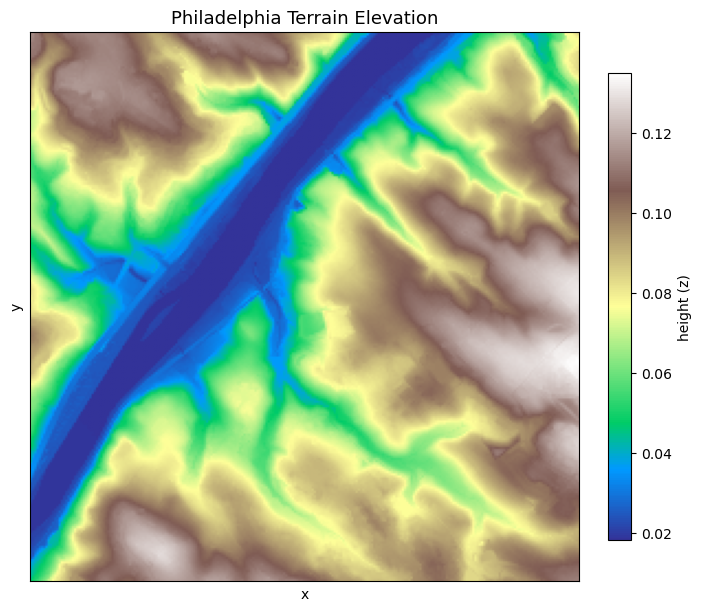

In [5]:
from scipy.interpolate import griddata as _griddata

all_x_t = np.unique(node_features[:, 0])
all_y_t = np.unique(node_features[:, 1])
gx, gy = np.meshgrid(all_x_t, all_y_t)

height_grid = _griddata(
    node_features[:, :2],
    node_features[:, 2],
    (gx, gy),
    method="linear",
)
height_nearest = _griddata(
    node_features[:, :2],
    node_features[:, 2],
    (gx, gy),
    method="nearest",
)
height_grid = np.where(np.isnan(height_grid), height_nearest, height_grid)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(height_grid, cmap="terrain", origin="lower")
ax.set_title("Philadelphia Terrain Elevation", fontsize=13)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, label="height (z)", shrink=0.85)
plt.show()

In [6]:
api = wandb.Api()
preds_by_run = {}
label_by_run = {}
mae_by_run = {}
layer_by_run = {}
p_by_run = {}

for _, row in df_res.iterrows():
    run_name = row["name"]
    run_id = row["id"]
    layer_type = row["layer_type"]
    test_mae_val = row.get("test_mae", np.nan)
    if pd.isna(test_mae_val):
        print(f"  {run_id} [{layer_type}]: test_mae is NaN, skipping")
        continue

    run_obj = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
    p_val = run_obj.config.get("p", None)
    log_dir = run_obj.config.get("log_dir")

    label_by_run[run_id] = f"{layer_type} p={p_val} ({run_id})"
    mae_by_run[run_id] = test_mae_val
    layer_by_run[run_id] = layer_type
    p_by_run[run_id] = p_val

    if log_dir is None:
        print(f"  {run_id} [{layer_type} p={p_val}]: no log_dir in wandb config, skipping")
        continue
    preds_path = Path(log_dir) / "preds.csv"
    if not preds_path.exists():
        print(f"  {run_id} [{layer_type} p={p_val}]: preds.csv not found at {preds_path}")
        continue
    preds_df = pd.read_csv(preds_path)
    preds_by_run[run_id] = preds_df
    print(f"  {run_id} [{layer_type} p={p_val}]: loaded {len(preds_df)} predictions "
          f"(MAE={preds_df['pred_maes'].mean():.4f})")

print(f"\nLoaded predictions for {len(preds_by_run)} runs")

  jafr7zmw [SparseGT p=4]: loaded 49750 predictions (MAE=0.1592)
  n3dv4tpn [SparseGT p=4]: loaded 49750 predictions (MAE=0.2708)
  gc3f2hht [SparseGT p=2]: loaded 49750 predictions (MAE=1.8269)
  1j4rbc5m [SparseGT p=2]: loaded 49750 predictions (MAE=2.0966)
  xz4huxs0 [SparseGT p=1]: loaded 49750 predictions (MAE=20.7336)
  n96ztr1i [SparseGT p=1]: loaded 49750 predictions (MAE=22.3435)
  lv8iakdi [SparseGT]: test_mae is NaN, skipping
  o2p3a15w [TAGConv p=4]: loaded 49750 predictions (MAE=0.0544)
  q9kzdbwe [TAGConv p=4]: loaded 49750 predictions (MAE=0.0544)
  1tuj6k34 [TAGConv p=2]: loaded 49750 predictions (MAE=0.0585)
  2lzyequv [TAGConv p=2]: loaded 49750 predictions (MAE=0.0585)
  msw5c138 [TAGConv p=1]: loaded 49750 predictions (MAE=0.5121)
  8xgdxquc [TAGConv p=1]: loaded 49750 predictions (MAE=0.5121)
  14j9mci0 [TAGConv]: test_mae is NaN, skipping

Loaded predictions for 12 runs


In [7]:
ref_preds = list(preds_by_run.values())[0]
src_ids = np.unique(ref_preds["srcs"].astype(int).values)
src_coords = node_features[src_ids, :2]
src_order = np.lexsort((src_coords[:, 0], src_coords[:, 1]))
sorted_srcs = src_ids[src_order]

n_sources_to_plot = min(9, len(sorted_srcs))
source_positions = np.linspace(0, len(sorted_srcs) - 1, n_sources_to_plot, dtype=int)
sources_to_plot = sorted_srcs[source_positions]

all_x = np.unique(node_features[:, 0])
all_y = np.unique(node_features[:, 1])
grid_nx = len(all_x)
grid_ny = len(all_y)
sp_grid_size = max(grid_nx, grid_ny)
print(f"Terrain grid: {grid_nx} x {grid_ny}")

sparse_by_p = {}
gcn_by_p = {}
for rid in preds_by_run:
    p_val = p_by_run.get(rid)
    if layer_by_run.get(rid) == "SparseGT":
        sparse_by_p.setdefault(p_val, []).append(rid)
    elif layer_by_run.get(rid) == "TAGConv":
        gcn_by_p.setdefault(p_val, []).append(rid)

for p_val in sparse_by_p:
    sparse_by_p[p_val].sort(key=lambda rid: mae_by_run.get(rid, float("inf")))
for p_val in gcn_by_p:
    gcn_by_p[p_val].sort(key=lambda rid: mae_by_run.get(rid, float("inf")))

all_p_values = sorted(set(sparse_by_p.keys()) & set(gcn_by_p.keys()))
comparison_pairs = []
for p_val in all_p_values:
    best_sparse = sparse_by_p[p_val][0]
    best_gcn = gcn_by_p[p_val][0]
    comparison_pairs.append((p_val, best_sparse, best_gcn))

print(f"Shared source ids for all plots: {sources_to_plot.tolist()}")
for p_val, sparse_id, gcn_id in comparison_pairs:
    print(
        f"p={p_val}: {label_by_run[sparse_id]} (mae={mae_by_run[sparse_id]:.4f}) "
        f"vs {label_by_run[gcn_id]} (mae={mae_by_run[gcn_id]:.4f})"
    )

Terrain grid: 250 x 250
Shared source ids for all plots: [747, 6470, 13955, 22444, 32467, 40405, 48185, 53619, 62394]
p=1: SparseGT p=1 (xz4huxs0) (mae=20.7336) vs TAGConv p=1 (msw5c138) (mae=0.5121)
p=2: SparseGT p=2 (gc3f2hht) (mae=1.8269) vs TAGConv p=2 (1tuj6k34) (mae=0.0585)
p=4: SparseGT p=4 (jafr7zmw) (mae=0.1592) vs TAGConv p=4 (o2p3a15w) (mae=0.0544)


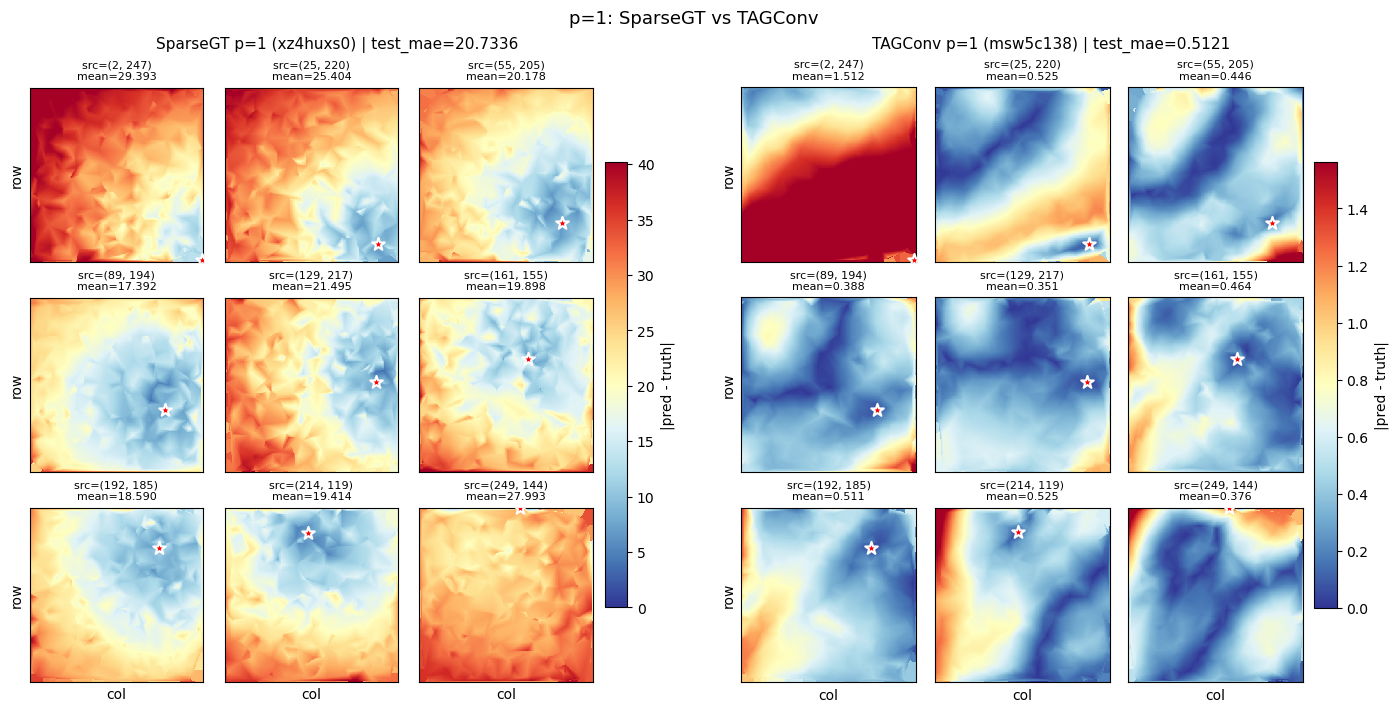

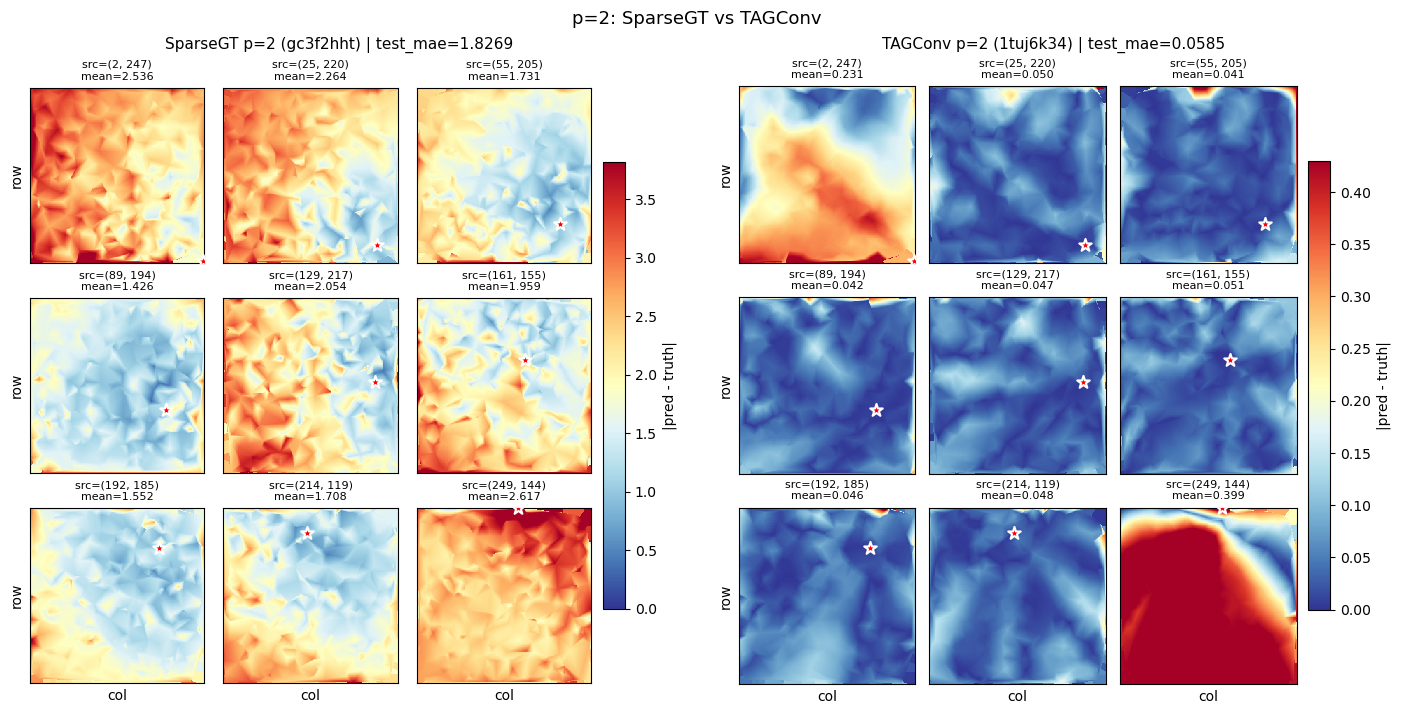

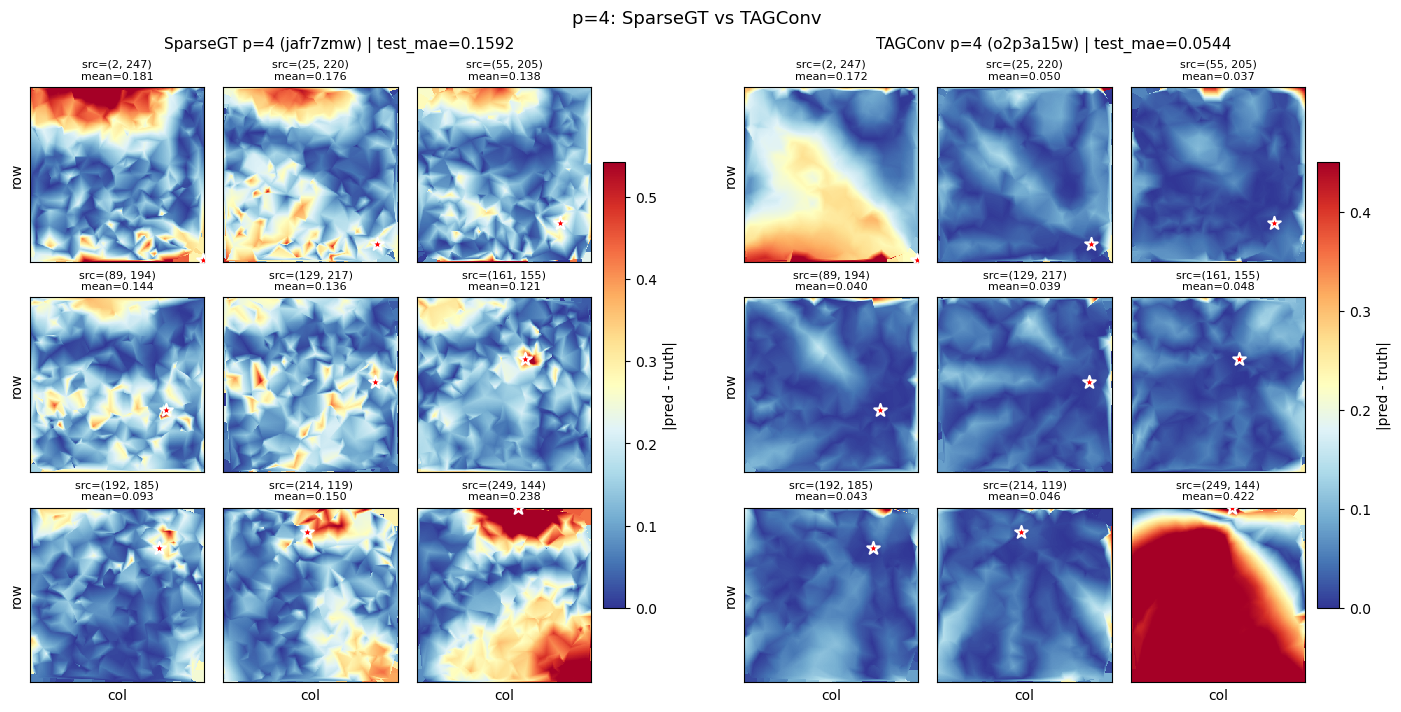

In [8]:
from scipy.interpolate import griddata

grid_x, grid_y = np.meshgrid(all_x, all_y)


def build_interpolated_maps(preds_df, sources_to_plot):
    preds_df = preds_df.copy()
    preds_df["srcs"] = preds_df["srcs"].astype(int)
    preds_df["tars"] = preds_df["tars"].astype(int)

    maps = []
    source_stats = []
    for src in sources_to_plot:
        src = int(src)
        src_rows = preds_df[preds_df["srcs"] == src]
        target_ids = src_rows["tars"].to_numpy()
        target_xy = node_features[target_ids, :2]
        target_errors = src_rows["pred_maes"].to_numpy()

        if len(target_xy) > 0:
            dist_linear = griddata(
                target_xy,
                target_errors,
                (grid_x, grid_y),
                method="linear",
            )
            dist_nearest = griddata(
                target_xy,
                target_errors,
                (grid_x, grid_y),
                method="nearest",
            )
            dist_2d = np.where(np.isnan(dist_linear), dist_nearest, dist_linear)
        else:
            dist_2d = np.full((grid_ny, grid_nx), np.nan)

        src_xy = node_features[src, :2]
        src_col = int(np.searchsorted(all_x, src_xy[0]))
        src_row = int(np.searchsorted(all_y, src_xy[1]))
        mean_err = src_rows["pred_maes"].mean() if len(src_rows) > 0 else np.nan

        maps.append(dist_2d)
        source_stats.append((src_row, src_col, mean_err))

    return maps, source_stats


def plot_run_grid(subfig, run_id):
    preds_df = preds_by_run[run_id]
    dist_maps, source_stats = build_interpolated_maps(preds_df, sources_to_plot)
    run_errors = preds_df["pred_maes"].to_numpy()
    run_vmin, run_vmax = 0, np.percentile(run_errors, 99)

    axes = subfig.subplots(3, 3)
    axes = axes.flatten()
    im = None

    for i, (dist_2d, (src_row, src_col, mean_err)) in enumerate(zip(dist_maps, source_stats)):
        ax = axes[i]
        im = ax.imshow(
            dist_2d,
            cmap="RdYlBu_r",
            origin="lower",
            vmin=run_vmin,
            vmax=run_vmax,
            interpolation="nearest",
        )
        ax.scatter(
            src_col,
            src_row,
            c="red",
            s=90,
            marker="*",
            edgecolors="white",
            linewidths=1.5,
            zorder=5,
        )
        ax.set_title(f"src=({src_row}, {src_col})\nmean={mean_err:.3f}", fontsize=8)
        if i % 3 == 0:
            ax.set_ylabel("row")
        else:
            ax.set_ylabel("")
        if i >= 6:
            ax.set_xlabel("col")
        else:
            ax.set_xlabel("")
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(sources_to_plot):]:
        ax.axis("off")

    label = label_by_run.get(run_id, run_id)
    test_mae = mae_by_run.get(run_id, np.nan)
    subfig.suptitle(f"{label} | test_mae={test_mae:.4f}", fontsize=11)
    subfig.colorbar(im, ax=axes.tolist(), label="|pred - truth|", shrink=0.75, pad=0.02)


for p_val, sparse_id, gcn_id in comparison_pairs:
    fig = plt.figure(figsize=(14, 7), constrained_layout=True)
    left_subfig, right_subfig = fig.subfigures(1, 2, wspace=0.04)

    plot_run_grid(left_subfig, sparse_id)
    plot_run_grid(right_subfig, gcn_id)

    fig.suptitle(
        f"p={p_val}: SparseGT vs TAGConv",
        fontsize=13,
    )
    plt.show()

## Side-by-Side: SparseGT (data embedding) vs TAGConv p=4

In [9]:
SGT_RUN_ID = "qq4v7qgk"
TAG_RUN_ID = "o2p3a15w"

api_cmp = wandb.Api()
cmp_runs = {}
for rid in [SGT_RUN_ID, TAG_RUN_ID]:
    run_obj = api_cmp.run(f"{ENTITY}/{PROJECT}/{rid}")
    cfg = run_obj.config
    smry = run_obj.summary
    log_dir = cfg.get("log_dir")
    preds_path = Path(log_dir) / "preds.csv"
    assert preds_path.exists(), f"preds.csv not found at {preds_path}"
    preds_df = pd.read_csv(preds_path)
    cmp_runs[rid] = {
        "config": cfg,
        "summary": smry,
        "preds": preds_df,
        "layer_type": cfg.get("layer_type", "SparseGT"), # Change! I am hardcoding for a plot
        "p": cfg.get("p", 4),
        "test_mae": smry.get("test_mae", np.nan),
        "best_val_mae": smry.get("best_val_mae", np.nan),
        "embedding_mode": cfg.get("sparse_gt_embedding_mode", "N/A"),
    }
    print(f"  {rid} [{cmp_runs[rid]['layer_type']}]: "
          f"p={cmp_runs[rid]['p']}, test_mae={cmp_runs[rid]['test_mae']:.4f}, "
          f"loaded {len(preds_df)} predictions")

CommError: Could not find run <Run alelab/manifold-transformers-dev/qq4v7qgk (None)>

Shared source ids: [747, 6470, 13955, 22444, 32467, 40405, 48185, 53619, 62394]
Shared color range: [0.0000, 0.2706]


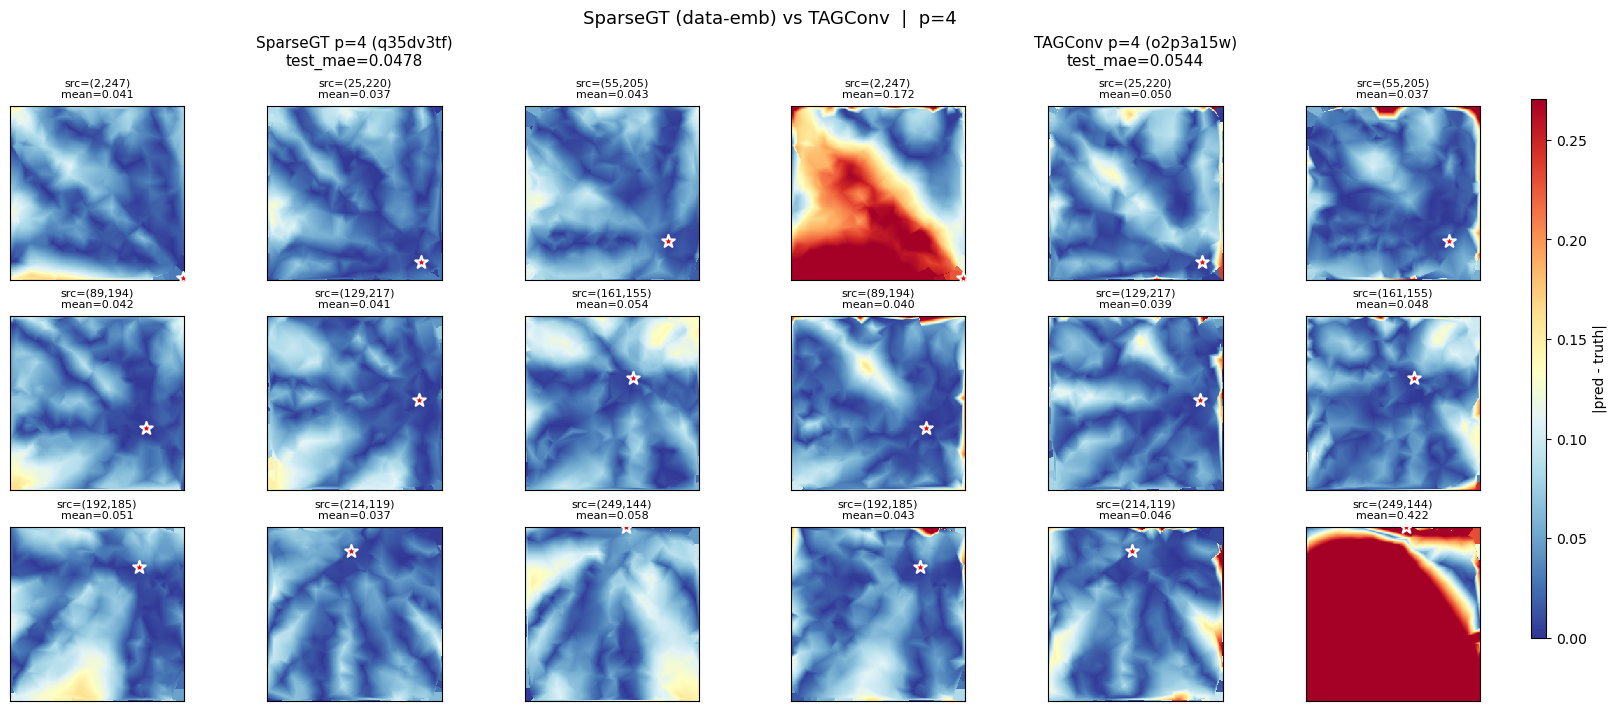

In [ ]:
from scipy.interpolate import griddata as _griddata_cmp

all_x_c = np.unique(node_features[:, 0])
all_y_c = np.unique(node_features[:, 1])
grid_x_c, grid_y_c = np.meshgrid(all_x_c, all_y_c)

ref_preds_c = cmp_runs[SGT_RUN_ID]["preds"]
src_ids_c = np.unique(ref_preds_c["srcs"].astype(int).values)
src_coords_c = node_features[src_ids_c, :2]
src_order_c = np.lexsort((src_coords_c[:, 0], src_coords_c[:, 1]))
sorted_srcs_c = src_ids_c[src_order_c]
n_sources_c = min(9, len(sorted_srcs_c))
positions_c = np.linspace(0, len(sorted_srcs_c) - 1, n_sources_c, dtype=int)
srcs_to_plot_c = sorted_srcs_c[positions_c]
print(f"Shared source ids: {srcs_to_plot_c.tolist()}")


def build_maps_cmp(preds_df):
    pdf = preds_df.copy()
    pdf["srcs"] = pdf["srcs"].astype(int)
    pdf["tars"] = pdf["tars"].astype(int)
    maps, stats = [], []
    for src in srcs_to_plot_c:
        src = int(src)
        rows = pdf[pdf["srcs"] == src]
        tids = rows["tars"].to_numpy()
        txy = node_features[tids, :2]
        terr = rows["pred_maes"].to_numpy()
        if len(txy) > 0:
            dl = _griddata_cmp(txy, terr, (grid_x_c, grid_y_c), method="linear")
            dn = _griddata_cmp(txy, terr, (grid_x_c, grid_y_c), method="nearest")
            d2d = np.where(np.isnan(dl), dn, dl)
        else:
            d2d = np.full(grid_x_c.shape, np.nan)
        sxy = node_features[src, :2]
        sc = int(np.searchsorted(all_x_c, sxy[0]))
        sr = int(np.searchsorted(all_y_c, sxy[1]))
        me = rows["pred_maes"].mean() if len(rows) > 0 else np.nan
        maps.append(d2d)
        stats.append((sr, sc, me))
    return maps, stats


all_errors_cmp = np.concatenate([
    cmp_runs[SGT_RUN_ID]["preds"]["pred_maes"].to_numpy(),
    cmp_runs[TAG_RUN_ID]["preds"]["pred_maes"].to_numpy(),
])
shared_vmin, shared_vmax = 0, np.percentile(all_errors_cmp, 99)
print(f"Shared color range: [{shared_vmin:.4f}, {shared_vmax:.4f}]")


def plot_subfig_cmp(subfig, rid):
    info = cmp_runs[rid]
    maps, stats = build_maps_cmp(info["preds"])

    axes = subfig.subplots(3, 3)
    axes = axes.flatten()
    im = None
    for i, (d2d, (sr, sc, me)) in enumerate(zip(maps, stats)):
        ax = axes[i]
        im = ax.imshow(d2d, cmap="RdYlBu_r", origin="lower",
                       vmin=shared_vmin, vmax=shared_vmax, interpolation="nearest")
        ax.scatter(sc, sr, c="red", s=90, marker="*",
                   edgecolors="white", linewidths=1.5, zorder=5)
        ax.set_title(f"src=({sr},{sc})\nmean={me:.3f}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[n_sources_c:]:
        ax.axis("off")

    label = f"{info['layer_type']} p={info['p']} ({rid})"
    subfig.suptitle(f"{label}\ntest_mae={info['test_mae']:.4f}", fontsize=11)
    return im


fig = plt.figure(figsize=(16, 7), constrained_layout=True)
left_subfig, mid_subfig, cbar_subfig = fig.subfigures(1, 3, width_ratios=[1, 1, 0.05])

im_left = plot_subfig_cmp(left_subfig, SGT_RUN_ID)
im_right = plot_subfig_cmp(mid_subfig, TAG_RUN_ID)

cbar_ax = cbar_subfig.add_axes([0.0, 0.1, 0.4, 0.8])
fig.colorbar(im_right, cax=cbar_ax, label="|pred - truth|")
fig.suptitle("SparseGT (data-emb) vs TAGConv  |  p=4", fontsize=13)
plt.show()